In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df[["sales", "profit"]].head())

Dataset loaded successfully!
Shape: (51290, 23)

First 5 rows:
   sales   profit
0  408.0  106.140
1  120.0   36.036
2   66.0   29.640
3   45.0  -26.055
4  114.0   37.770


In [3]:
X = df[["sales"]]
y = df["profit"]

print("Input (X): Sales")
print("Output (y): Profit")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 inputs:")
print(X.head())

print("\nFirst 5 outputs:")
print(y.head())

Input (X): Sales
Output (y): Profit

X shape: (51290, 1)
y shape: (51290,)

First 5 inputs:
   sales
0  408.0
1  120.0
2   66.0
3   45.0
4  114.0

First 5 outputs:
0    106.140
1     36.036
2     29.640
3    -26.055
4     37.770
Name: profit, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data split successfully!")

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Data split successfully!

Training data:
X_train: (41032, 1)
y_train: (41032,)

Testing data:
X_test: (10258, 1)
y_test: (10258,)


In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [6]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[  1.68131935  -9.43653516  -9.10953944  -2.56962502 280.44517126
  15.57863748 -10.74451804 187.08789299 -11.23501162  -3.0601186 ]


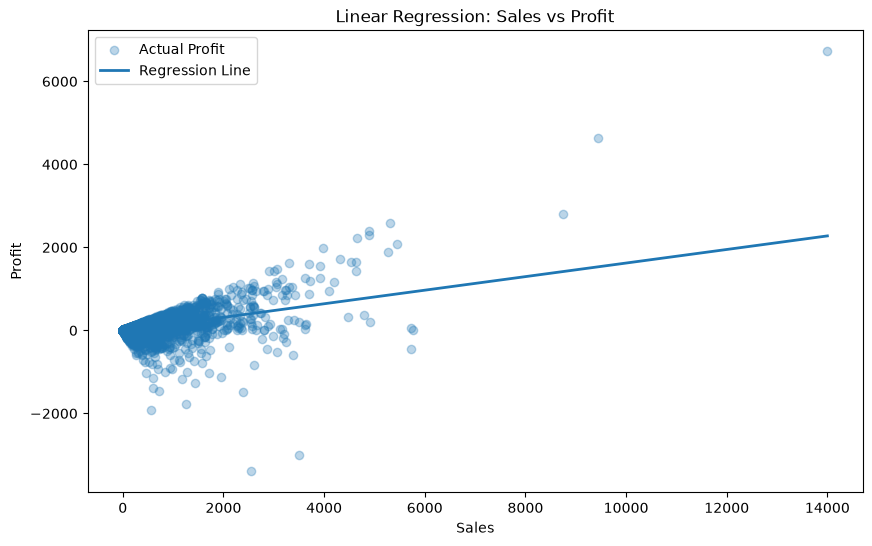

In [11]:
plot_df = pd.DataFrame({
    "sales": X_test["sales"].values,
    "actual_profit": y_test.values,
    "predicted_profit": y_pred
}).sort_values("sales")

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["sales"],
    plot_df["actual_profit"],
    alpha=0.3,
    label="Actual Profit"
)

plt.plot(
    plot_df["sales"],
    plot_df["predicted_profit"],
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Linear Regression: Sales vs Profit")
plt.legend()

plt.savefig(
    "sales_profit_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

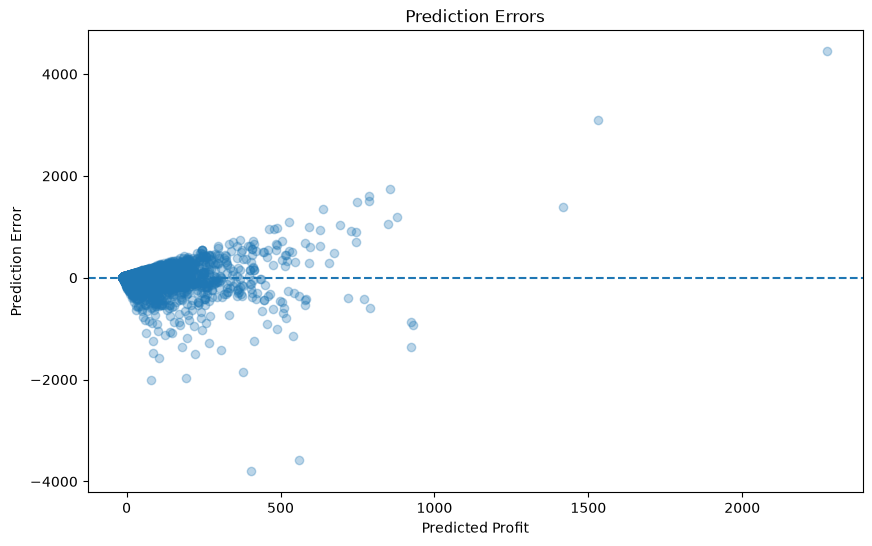

In [12]:
errors = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    errors,
    alpha=0.3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Profit")
plt.ylabel("Prediction Error")
plt.title("Prediction Errors")

plt.savefig(
    "prediction_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
print("Model Coefficient:", model.coef_[0])
print("Model Intercept:", model.intercept_)

print(
    f"\nEquation: Profit = "
    f"{model.coef_[0]:.4f} × Sales + "
    f"{model.intercept_:.4f}"
)

Model Coefficient: 0.16349786035869135
Model Intercept: -12.379496644766629

Equation: Profit = 0.1635 × Sales + -12.3795


In [10]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation
-----------------
Mean Absolute Error (MAE): 55.2924
R² Score: 0.3213


In [13]:
prediction_results = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred
})

prediction_results.to_csv(
    "prediction_results.csv",
    index=False
)

print("Prediction results saved successfully!")
print("\nFirst 10 results:")
print(prediction_results.head(10))

Prediction results saved successfully!

First 10 results:
   Actual Profit  Predicted Profit
0       -20.6850          1.681319
1        -0.4080         -9.436535
2         9.7200         -9.109539
3       -64.1400         -2.569625
4       560.7882        280.445171
5        34.2600         15.578637
6         4.4088        -10.744518
7       381.2375        187.087893
8         2.8200        -11.235012
9        12.0000         -3.060119
